In [1]:
%matplotlib widget

from blackjack_cpp import ProbabilisticRankShoe
from blackjack.blackjack_round import BJRound, BJStage, BJRules
from blackjack.actions import PlayerAction, DealerAction
from blackjack.cards import Card, Rank
import numpy as np
import time
from datetime import datetime
import os
import tqdm
from collections import deque
# from blackjack.shoe import ProbabilisticRankShoe
import time
from blackjack.floor_ceil_node import FloorCeilNode, SplitNode, DecisionNode, DealerCheckBJNode
from blackjack.dealer_sim import (
    run_dealer_cards_simulation,
    run_dealer_cards_simulation_recursive,
    load_realistic_combs_with_counts,
    _dealer_stand_or_bust,
    _run_dealer_cards_simulation
)
from blackjack.hand import ValueOnlyHand
from collections import defaultdict
import datetime
import matplotlib.pyplot as plt
from blackjack.tree_utils import iterate_nodes_by_levels
import os
from blackjack import abstract_node

In [2]:
from blackjack_cpp import RandomSampler


def change_random_sampler(shoe):
    new_shoe = ProbabilisticRankShoe(0, RandomSampler.create_next_sampler())
    for card in range(2, 12):
        new_shoe.set_number_of_rank_cards(
            card, shoe.get_number_of_rank_cards(card)
        )
    shoe = new_shoe
    return shoe



def run_dealer_cards_simulation_by_outcome(
    bj_round: BJRound,
    shoe: ProbabilisticRankShoe,
    n_dealer_sim_runs: int,
    depth_cutoff,
    reset_shoe_sampler: bool = True
):
    """Run Monte Carlo simulations for dealer play."""
    values = []
    dealer_bust_outcome = []
    dealer_stand_outcome = []
    dealer_other_outcome = []

    if shoe.is_dealer_card_locked():
        shoe.unlock_dealer_card()
        shoe = shoe.copy()
    
    for i in range(n_dealer_sim_runs):
        bj_round_copy = bj_round.copy()
        shoe_copy = shoe.copy()
        if reset_shoe_sampler:
            shoe_copy = change_random_sampler(shoe_copy)

        # Simulate dealer cards until round over
        while not bj_round_copy.get_stage() == BJStage.ROUND_OVER:
            possible_values = bj_round_copy.get_possible_next_card_ranks()
            card = shoe_copy.sample_and_burn_rank(possible_values)
            bj_round_copy.take_card(card)
        
        if len(bj_round_copy.dealer_hand) >= depth_cutoff:
            dealer_other_outcome.append(bj_round_copy.get_player_value())
        elif bj_round_copy.dealer_hand.is_bust():
            dealer_bust_outcome.append(bj_round_copy.get_player_value())
        else:
            dealer_stand_outcome.append(bj_round_copy.get_player_value())

        # Collect results
        values.append(bj_round_copy.get_player_value())
    return values, dealer_bust_outcome, dealer_stand_outcome, dealer_other_outcome

In [3]:
"abc"[:-1]

'ab'

In [28]:
from collections import Counter
from math import factorial
from itertools import product
from copy import copy


def get_final_combo(cards, upcard, dealer_no_blackjack):
    if dealer_no_blackjack and upcard == 11 and not set(cards) == {10}:
        cards = tuple(sorted(cards))
        # move tens to the back if possible
        # first card should not give blackjack to a dealer
        # but if dealer has A and combination cards are just A and T
        # then if cards are just sorted, dealer second card will be T 
        # and this is blackjack - we dont want this - we only simulate 
        # non-bj hands
        while cards[0] == 10:
            cards = cards[1:] + (10,)
        return cards
    else:
        return tuple(sorted(cards))


def _get_realistic_combinations_from_previous(
    upcard, dealer_hit_soft_17, dealer_no_blackjack,
    previous_depth_data   
):
    bust_counts = copy(previous_depth_data["bust_counts"])
    stand_counts = copy(previous_depth_data["stand_counts"])
    prev_other_counts = copy(previous_depth_data["other_counts"])
    other_counts = defaultdict(int)

    for combo, count in prev_other_counts.items():
        for card in range(2, 12):
            hand = ValueOnlyHand([upcard] + list(combo) + [card])

            final_combo = get_final_combo(hand.cards[1:], upcard, dealer_no_blackjack)
            if hand.is_bust():
                bust_counts[final_combo] += count
            elif _dealer_stand_or_bust(hand, dealer_hit_soft_17):
                stand_counts[final_combo] += count
            else:
                other_counts[final_combo] += count
            
                
    return _format_output(bust_counts, stand_counts, other_counts, upcard)


def get_realistic_combinations(
        depth, upcard, dealer_hit_soft_17, dealer_no_blackjack,
        previous_depth_data=None
    ):
    if previous_depth_data is not None:
        return _get_realistic_combinations_from_previous(
            upcard, dealer_hit_soft_17, dealer_no_blackjack,
            previous_depth_data
        )

    bust_counts = defaultdict(int)
    stand_counts = defaultdict(int)
    other_counts = defaultdict(int)

    for current_depth in range(1, depth):  # stops at depth-1
        for combo in product(range(2, 12), repeat=current_depth):
            if upcard + combo[0] == 21 and dealer_no_blackjack:
                continue
            hand = ValueOnlyHand([upcard])
            stopped_early = False

            for v in combo:
                if _dealer_stand_or_bust(hand, dealer_hit_soft_17):
                    stopped_early = True
                    break
                hand.add_card(v)
            if stopped_early:
                continue

            final_combo = get_final_combo(hand.cards[1:], upcard, dealer_no_blackjack)
            if hand.is_bust():
                bust_counts[final_combo] += 1
            elif _dealer_stand_or_bust(hand, dealer_hit_soft_17):
                stand_counts[final_combo] += 1

    for combo in product(range(2, 12), repeat=depth):
        if upcard + combo[0] == 21 and dealer_no_blackjack:
            continue
        hand = ValueOnlyHand([upcard])
        stopped_early = False

        for v in combo:
            if _dealer_stand_or_bust(hand, dealer_hit_soft_17):
                stopped_early = True
                break
            hand.add_card(v)
        if stopped_early:
            continue

        final_combo = get_final_combo(hand.cards[1:], upcard, dealer_no_blackjack)
        if hand.is_bust():
            bust_counts[final_combo] += 1
        elif _dealer_stand_or_bust(hand, dealer_hit_soft_17):
            stand_counts[final_combo] += 1
        else:
            other_counts[final_combo] += 1

    return _format_output(bust_counts, stand_counts, other_counts, upcard)


def _format_output(bust_counts, stand_counts, other_counts, upcard):
    bust_combos = sorted(bust_counts.keys())
    bust_combos_data = [(comb, bust_counts[comb]) for comb in bust_combos]

    stand_combos = sorted(stand_counts.keys())
    stand_combos_data = [(comb, stand_counts[comb]) for comb in stand_combos]
    stand_values = np.array([
        ValueOnlyHand([upcard, *comb]).get_best_value() for comb in stand_combos
    ])

    stand_combos = sorted(other_counts.keys())
    other_combos_data = [(comb, other_counts[comb]) for comb in other_counts]

    return dict(
        bust_combos_data=bust_combos_data, 
        stand_combos_data=stand_combos_data, 
        stand_values=stand_values, 
        other_combos_data=other_combos_data,
        bust_counts=bust_counts,
        stand_counts=stand_counts,
        other_counts=other_counts
    )

In [29]:

precomputed_combinations_with_counts_no_bj_new = dict()
precomputed_combinations_with_counts_new = dict()

# for depth in range(8, 14):
#     print(depth, "started")
#     precomputed_combinations_with_counts_new[depth] = dict()
#     precomputed_combinations_with_counts_no_bj_new[depth] = dict()
#     for upcard in range(2, 12):
#         precomputed_combinations_with_counts_no_bj_new[depth][upcard] = get_realistic_combinations(
#             depth, upcard, dealer_hit_soft_17=False, dealer_no_blackjack=True
#         )
#         precomputed_combinations_with_counts_new[depth][upcard] = get_realistic_combinations(
#             depth, upcard, dealer_hit_soft_17=False, dealer_no_blackjack=False
#         )
#     print(depth, "done")

In [30]:
precomputed_combinations_with_counts.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8])

In [31]:
import pickle

_combinations_with_counts_no_bj = dict()
_combinations_with_counts = dict()

for depth in range(1, 17):
    print(depth)
    _combinations_with_counts[depth] = dict()
    _combinations_with_counts_no_bj[depth] = dict()
    for upcard in range(2, 12):
        print(upcard, end=" ")
        _combinations_with_counts[depth][upcard] = get_realistic_combinations(
            depth, upcard, dealer_hit_soft_17=False, dealer_no_blackjack=True,
            previous_depth_data=_combinations_with_counts.get(depth-1, {}).get(upcard, None)
        )
        _combinations_with_counts_no_bj[depth][upcard] = get_realistic_combinations(
            depth, upcard, dealer_hit_soft_17=False, dealer_no_blackjack=True,
            previous_depth_data=_combinations_with_counts_no_bj.get(depth-1, {}).get(upcard, None)
        )
    print()

1
2 3 4 5 6 7 8 9 10 11 
2
2 3 4 5 6 7 8 9 10 11 
3
2 3 4 5 6 7 8 9 10 11 
4
2 3 4 5 6 7 8 9 10 11 
5
2 3 4 5 6 7 8 9 10 11 
6
2 3 4 5 6 7 8 9 10 11 
7
2 3 4 5 6 7 8 9 10 11 
8
2 3 4 5 6 7 8 9 10 11 
9
2 3 4 5 6 7 8 9 10 11 
10
2 3 4 5 6 7 8 9 10 11 
11
2 3 4 5 6 7 8 9 10 11 
12
2 3 4 5 6 7 8 9 10 11 
13
2 3 4 5 6 7 8 9 10 11 
14
2 3 4 5 6 7 8 9 10 11 
15
2 3 4 5 6 7 8 9 10 11 
16
2 3 4 5 6 7 8 9 10 11 


In [ ]:
_combinations_with_counts_no_bj[11][11]["other_combos_data"]

[((6, 11, 11, 11, 11, 11, 11, 11, 11, 11), 1)]

In [53]:
precomputed_combinations_with_counts_no_bj = _combinations_with_counts_no_bj
precomputed_combinations_with_counts = _combinations_with_counts

In [54]:
import pickle


with open("combinations/combinations_with_counts_no_bj_d13.pkl", "wb") as f:
    pickle.dump(
        precomputed_combinations_with_counts_no_bj,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

with open("combinations/combinations_with_counts_d13.pkl", "wb") as f:
    pickle.dump(
        precomputed_combinations_with_counts_no_bj,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

In [37]:
with open("combinations/combinations_with_counts_no_bj.pkl", "rb") as f:
    precomputed_combinations_with_counts_no_bj = pickle.load(f)

with open("combinations/combinations_with_counts.pkl", "rb") as f:
    precomputed_combinations_with_counts = pickle.load(f)

In [38]:
precomputed_combinations_with_counts_no_bj[8].keys()

dict_keys([2, 3, 4])

In [39]:
for depth in range(1, 8):
    print("depth ", depth)
    for upcard in range(2, 12):
        for k in _combinations_with_counts_no_bj[depth][upcard].keys():
            k_equal = np.all(
                _combinations_with_counts_no_bj[depth][upcard][k]
                == precomputed_combinations_with_counts_no_bj[depth][upcard][k]
            )
            print(
                k,
                k_equal   
            )
            assert k_equal

depth  1
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data True
stand_combos_data True
stand_values True
other_combos_data True
bust_counts True
stand_counts True
other_counts True
bust_combos_data T

In [ ]:
def get_cards_probability(cards, shoe, possible_first_card=None):
    prob = 1
    burned_cards = []
    for i, card in enumerate(cards):
        if i == 0:
            possible_cards = possible_first_card
        else:
            possible_cards = None
        probs = shoe.get_rank_value_probabilities(possible_cards)
        if card not in probs or probs[card] == 0:
            prob = 0
            break

        prob = prob * probs[card]
        shoe.burn_rank_value(card)
        burned_cards.append(card)
    
    for card in burned_cards:
        shoe.add_rank_value(card)
    
    return prob


import pickle

with open("combinations/combinations_with_counts_no_bj.pkl", "rb") as f:
    precomputed_combinations_with_counts_no_bj = pickle.load(f)

with open("combinations/combinations_with_counts.pkl", "rb") as f:
    precomputed_combinations_with_counts = pickle.load(f)


def run_dealer_cards_simulation_combo(
    bj_round: BJRound,
    shoe: ProbabilisticRankShoe,
    n_dealer_sim_runs: int = None,
    n_full_sample: int = 5,
    verbose = False
):
    dealer_hand: ValueOnlyHand = bj_round.dealer_hand.copy()
    dealer_hit_soft_17 = bj_round.rules.dealer_hits_soft_17
    assert dealer_hand.size() == 1
    assert len(bj_round.player_hands) == 1
    assert bj_round.get_stage() == BJStage.DEALER_CARD
    assert not bj_round.player_hands[0].is_natural_blackjack()


    if shoe.is_dealer_card_locked():
        shoe = shoe.copy()
        shoe.unlock_dealer_card()
        
    player_hand_value = bj_round.player_hands[0].get_best_value()

    assert not bj_round.rules.dealer_hits_soft_17
    if bj_round.rules.dealer_checks_blackjack:
        assert not bj_round.dealer_has_bj_after_check
        data = precomputed_combinations_with_counts_no_bj[n_full_sample][dealer_hand.cards[0]]
    else:
        data = precomputed_combinations_with_counts[n_full_sample][dealer_hand.cards[0]]
        
    possible_second_card = bj_round.get_possible_next_card_ranks()

    bust_combos_data = data['bust_combos_data']
    stand_combos_data = data['stand_combos_data']
    other_combos_data = data['other_combos_data']
    stand_values = data['stand_values']

    total_p = 0 

    dealer_bust_p = 0
    for i_comb, (combo, num_perms) in enumerate(bust_combos_data):
        prob = get_cards_probability(combo, shoe, possible_second_card)
        if prob != 0:
            prob = prob * num_perms
            total_p += prob
            dealer_bust_p += prob
    
    ev_stand = np.zeros(len(stand_combos_data))
    prob_stand = np.zeros(len(stand_combos_data))
    ev_stand[player_hand_value > stand_values] = 1
    ev_stand[player_hand_value == stand_values] = 0
    ev_stand[player_hand_value < stand_values] = -1
    for i_comb, (combo, num_perms) in enumerate(stand_combos_data):
        prob = get_cards_probability(combo, shoe, possible_second_card)
        if prob != 0:
            prob = prob * num_perms
            total_p += prob
            prob_stand[i_comb] = prob

    ev_other = np.zeros(len(other_combos_data))
    prob_other= np.zeros(len(other_combos_data))
    
    for i_comb, (combo, num_perms) in enumerate(other_combos_data):
        prob = 1
        impossible = False
        burned_cards = []
        for i_card, card in enumerate(combo):
            if i_card == 0:
                probs = shoe.get_rank_value_probabilities(possible_second_card)
            else:
                probs = shoe.get_rank_value_probabilities()
            if card not in probs or probs[card] == 0:
                impossible = True
                break
            prob = prob * probs[card]
            shoe.burn_rank_value(card)
            burned_cards.append(card)
            dealer_hand.add_card(card)
  
        if impossible:
            for card in burned_cards:
                shoe.add_rank_value(card) 
                dealer_hand.pop_card()
            continue
        
        prob = prob * num_perms
        total_p += prob
        prob_other[i_comb] = prob

        assert not _dealer_stand_or_bust(dealer_hand, dealer_hit_soft_17)
        sim_values = _run_dealer_cards_simulation(
            player_hand_value,
            dealer_hand,
            shoe,
            num_perms,
            dealer_hit_soft_17,
            new_random_sampler=False
        )
        ev_other[i_comb] = np.mean(sim_values)
        for card in burned_cards:
            shoe.add_rank_value(card)
            dealer_hand.pop_card()
    

    p_bust = dealer_bust_p
    ev_bust_value = 1 * dealer_bust_p
    p_stand = prob_stand.sum()
    p_other = total_p - p_bust - p_stand
    ev_stand_value = ev_stand.dot(prob_stand).item()
    ev_other_value = ev_other.dot(prob_other).item()
    if verbose:
        print("p_bust =", p_bust)
        print("p_stand =", p_stand, "ev_stand_value =", ev_stand_value)
        print("p_other =", p_other, "ev_other_value =", ev_other_value)
        print("p_total =", total_p)
    final_value = bj_round.bet_unit * (
        ev_other_value
        + ev_stand_value
        + ev_bust_value
    )
    if np.abs(total_p - 1) > 1e-8:
        raise RuntimeError(f"Probability does not sum to 1 , total_p = {total_p}")
    return final_value

In [12]:
data = precomputed_combinations_with_counts[1][11]
bust_combos_data = data['bust_combos_data']
stand_combos_data = data['stand_combos_data']
stand_values = data['stand_values']
other_combos_data = data['other_combos_data']

In [13]:
other_combos_data[0]

((2,), 1)

In [14]:
# print(stand_values)

# print()
# print(bust_combos_data)
# print()
# print(stand_combos_data)
# print()
# print(other_combos_data)

In [15]:
rules = BJRules(
    dealer_checks_blackjack=True,
    dealer_hits_soft_17=False,
    allow_late_surrender=False,
    allow_early_surrender_on_ten=False,
    allow_early_surrender_on_ace=False,
    allow_early_surrender_on_all=False,
    dealer_shows_card_on_surrender=False,
    allow_insurance_vs_ace=True,
    natural_blackjack_payout=3/2,
    surrender_payout=1/2,
    insurance_payout=2/1,
    max_splits_allowed=1,
    allow_action_on_split_aces=True,
    allow_double_after_split=True,
    allow_double_on_soft=True,
    allow_split_different_tens=True
)

In [16]:
bj_round = BJRound(rules)


def get_shoe():
    shoe = ProbabilisticRankShoe(0, 42)
    for c in range(2, 12):
        shoe.set_number_of_rank_cards(c, c)
    return shoe

shoe = get_shoe()

bj_round.start_round(100)

cards = [
    Card(Rank.ACE),
    Card(Rank.ACE),
    Card(Rank.ACE) 
]

# cards = [
#     Card(Rank.NINE),
#     Card(Rank.SEVEN),
#     Card(Rank.SIX) 
# ]

cards = [c.rank_value() for c in cards]

bj_round.take_card(cards[0])
bj_round.take_card(cards[1])
bj_round.take_card(cards[2])

shoe.burn_rank_value(cards[0])
shoe.burn_rank_value(cards[1])
shoe.burn_rank_value(cards[2])

if PlayerAction.REFUSE_INSURANCE in bj_round.get_available_actions():
    bj_round.take_action(PlayerAction.REFUSE_INSURANCE)
if DealerAction.CONFIRM_NO_BLACKJACK in bj_round.get_available_actions():
    bj_round.take_action(DealerAction.CONFIRM_NO_BLACKJACK)
bj_round.take_action(PlayerAction.STAND)


In [17]:
print(str(shoe))

ProbabilisticRankShoe
  p(2) = 3.22581%
  p(3) = 4.83871%
  p(4) = 6.45161%
  p(5) = 8.06452%
  p(6) = 9.67742%
  p(7) = 11.2903%
  p(8) = 12.9032%
  p(9) = 14.5161%
  p(10) = 16.129%
  p(11) = 12.9032%



In [18]:
value_rec = run_dealer_cards_simulation_recursive(
    bj_round,
    shoe.copy(),
    n_dealer_sim_runs=1,
    n_full_sample=3
)

In [19]:
value_combs = []

In [20]:
value_comb = run_dealer_cards_simulation_combo(
    bj_round,
    shoe.copy(),
    n_dealer_sim_runs=1,
    n_full_sample=1,
    verbose=True
)
value_combs.append(value_comb)

p_bust = 0
p_stand = 0.576923076923077 ev_stand_value = -0.576923076923077
p_other = 0.423076923076923 ev_other_value = -0.23076923076923078
p_total = 1.0


In [21]:
set(value_combs)

{-80.76923076923077}

In [22]:
# total_p 1.000000000000002
# p_bust 0.1150213630730473
# p_stand 0.884947962554003 ev_stand -8.84947962554003
# p_other 3.067437295167785e-05

In [23]:
value_rec, value_comb

(np.float64(-78.62232030264819), -80.76923076923077)

In [24]:
values, dealer_bust_outcome, dealer_stand_outcome, dealer_other_outcome =\
    run_dealer_cards_simulation_by_outcome(
        bj_round,
        shoe,
        100000,
        2+3
    )

In [25]:
print("p_bust", len(dealer_bust_outcome) / len(values))
print("p_stand", len(dealer_stand_outcome) / len(values))
print("p_other", len(dealer_other_outcome) / len(values))
print(np.mean(values))

p_bust 0.05981
p_stand 0.86628
p_other 0.07391
-80.574


In [26]:
np.mean(dealer_stand_outcome)

np.float64(-100.0)

In [27]:
expected = -0.154 * 10
print(expected) # 97 vs 6

-1.54


In [28]:
bj_round.get_stage()

<BJStage.DEALER_CARD: 7>

In [29]:
old_sim_values = []

n_sim_runs = 1000
 
for i in tqdm.tqdm(range(n_sim_runs)):
    old_simulation_value = \
        run_dealer_cards_simulation(bj_round, shoe, n_dealer_sim_runs=1000)
    old_sim_values.append(old_simulation_value)

100%|██████████| 1000/1000 [00:11<00:00, 88.09it/s]


In [30]:
old_simulation_value = np.mean(old_sim_values)
old_simulation_value

np.float64(-80.533)

In [31]:
values_rec_by_depth = dict()


n_sim_runs = 1000
for depth_i in range(1, 8):
    values_rec = []
    t0 = time.time()
    for i in tqdm.tqdm(range(n_sim_runs)):
        value_comb = run_dealer_cards_simulation_recursive(
            bj_round,
            shoe,
            n_dealer_sim_runs=1,
            n_full_sample=depth_i
        )
        values_rec.append(value_comb)
    values_rec_by_depth[depth_i] = values_rec
    t1 = time.time()
    print(f"Depth {depth_i} took {(t1 - t0) / n_sim_runs * 1000 } milliseconds")

100%|██████████| 1000/1000 [00:00<00:00, 11430.40it/s]


Depth 1 took 0.08864116668701172 milliseconds


100%|██████████| 1000/1000 [00:00<00:00, 2349.10it/s]


Depth 2 took 0.4268677234649658 milliseconds


100%|██████████| 1000/1000 [00:01<00:00, 577.42it/s]


...

Depth 5 took 10.315258264541626 milliseconds


100%|██████████| 1000/1000 [00:15<00:00, 62.54it/s]


Depth 6 took 15.990048408508299 milliseconds


100%|██████████| 1000/1000 [00:20<00:00, 49.77it/s]

Depth 7 took 20.091517448425293 milliseconds


In [32]:
shoe2 = shoe.copy()
shoe3 = shoe.copy()
print([shoe.sample_rank() for i in range(10)])
print([shoe2.sample_rank() for i in range(10)])
print("="*10)
shoe2.reset_sampler()
print([shoe.sample_rank() for i in range(10)])
print([shoe2.sample_rank() for i in range(10)])
print([shoe3.sample_rank() for i in range(10)])
print("="*10)
shoe2.reset_sampler()
shoe3.reset_sampler()
print([shoe.sample_rank() for i in range(10)])
print([shoe2.sample_rank() for i in range(10)])
print([shoe3.sample_rank() for i in range(10)])

[10, 9, 10, 4, 11, 4, 9, 7, 6, 7]
[10, 9, 10, 4, 11, 4, 9, 7, 6, 7]
[2, 8, 9, 9, 10, 11, 10, 8, 3, 3]
[10, 10, 11, 11, 10, 8, 4, 8, 11, 8]
[10, 9, 10, 4, 11, 4, 9, 7, 6, 7]
[10, 5, 7, 4, 4, 4, 8, 8, 10, 4]
[9, 4, 8, 4, 9, 6, 10, 9, 9, 7]
[10, 3, 10, 8, 8, 9, 11, 9, 8, 11]


In [33]:
values_comb_by_depth = dict()


n_sim_runs = 1000
for depth_i in range(1, 8):
    values_comb = []
    t0 = time.time()
    for i in tqdm.tqdm(range(n_sim_runs)):
        shoe.reset_sampler()
        value_comb = run_dealer_cards_simulation_combo(
            bj_round,
            shoe,
            n_dealer_sim_runs=1,
            n_full_sample=depth_i
        )
        values_comb.append(value_comb)
    t1 = time.time()
    print(f"Depth {depth_i} took {(t1 - t0) / n_sim_runs * 1000 } milliseconds")
    values_comb_by_depth[depth_i] = values_comb

100%|██████████| 1000/1000 [00:00<00:00, 8913.94it/s]


Depth 1 took 0.11344504356384277 milliseconds


100%|██████████| 1000/1000 [00:00<00:00, 2160.75it/s]


Depth 2 took 0.4639618396759033 milliseconds


100%|██████████| 1000/1000 [00:01<00:00, 670.84it/s]


...

Depth 5 took 4.70972752571106 milliseconds


100%|██████████| 1000/1000 [00:05<00:00, 172.48it/s]


Depth 6 took 5.79862380027771 milliseconds


100%|██████████| 1000/1000 [00:06<00:00, 156.58it/s]

Depth 7 took 6.387295484542847 milliseconds


In [34]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt



sns.set_theme(style="whitegrid")  # optional styling

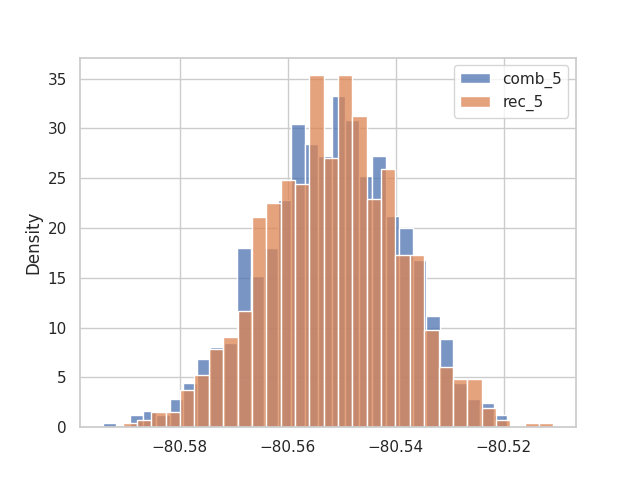

In [35]:
f, ax = plt.subplots()


for i in range(5, 6):
    sns.histplot(values_comb_by_depth[i], bins=30, axes=ax, label=f"comb_{i}", stat="density")

for i in range(5, 6):
    sns.histplot(values_rec_by_depth[i], bins=30, axes=ax, label=f"rec_{i}", stat="density")


# sns.histplot(values_comb, bins=30, color="green", axes=ax, label="comb", stat="density")


# ax.axvline(
#     old_simulation_value,
#     color="red", linestyle="--", linewidth=2,
#     label=f"Mean = {old_simulation_value}"
# )



plt.legend()
plt.show()

In [39]:
precomputed_combinations_with_counts_no_bj.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8])

In [40]:
precomputed_combinations_with_counts_no_bj[7].keys()

dict_keys([2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [42]:
precomputed_combinations_with_counts_no_bj[7][2].keys()

dict_keys(['bust_combos_data', 'stand_combos_data', 'stand_values', 'other_combos_data', 'bust_counts', 'stand_counts', 'other_counts'])

In [56]:
import json


keys = ['bust_combos_data', 'stand_combos_data', 'stand_values', 'other_combos_data']

last_depth = False
for depth in precomputed_combinations_with_counts_no_bj.keys():
    print("depth", depth)
    depth_data_no_bj = precomputed_combinations_with_counts_no_bj[depth]
    depth_data = precomputed_combinations_with_counts[depth]

    last_depth = True
    for dealer_upcard in depth_data.keys():
        upcard_data = depth_data[dealer_upcard]
        upcard_data = {k: upcard_data[k] for k in keys}
        upcard_data_no_bj = depth_data_no_bj[dealer_upcard]
        upcard_data_no_bj = {k: upcard_data_no_bj[k] for k in keys}

        if len(upcard_data["other_combos_data"]) > 0 or len(upcard_data_no_bj["other_combos_data"]) > 0:
            last_depth = False

        upcard_data["stand_values"] = upcard_data["stand_values"].tolist()
        upcard_data_no_bj["stand_values"] = upcard_data_no_bj["stand_values"].tolist()

        fname = f"combinations/s16_new/dealer_checked_no_bj/depth_{depth}_upcard_{dealer_upcard}.json"
        with open(fname, "w") as f:
            json.dump(upcard_data_no_bj, f)

        fname = f"combinations/s16_new/bj_not_checked/depth_{depth}_upcard_{dealer_upcard}.json"
        with open(fname, "w") as f:
            json.dump(upcard_data_no_bj, f)
    if last_depth:
        break

depth 1
depth 2
depth 3
depth 4
depth 5
depth 6
depth 7
depth 8
depth 9
depth 10
depth 11


In [46]:
upcard_data_no_bj["stand_values"].tolist()

[]